<a href="https://colab.research.google.com/github/ksaad20/Digital-Signal-Processing-Mathematics-to-Code-/blob/main/Chapter_1_Sampling_and_Quantization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The Math: Nyquist-Shannon theorem, aliasing, and quantization noise.

The Project: Build an ADC/DAC simulator that visually degrades audio or signals as you alter sampling rates and bit-depths.

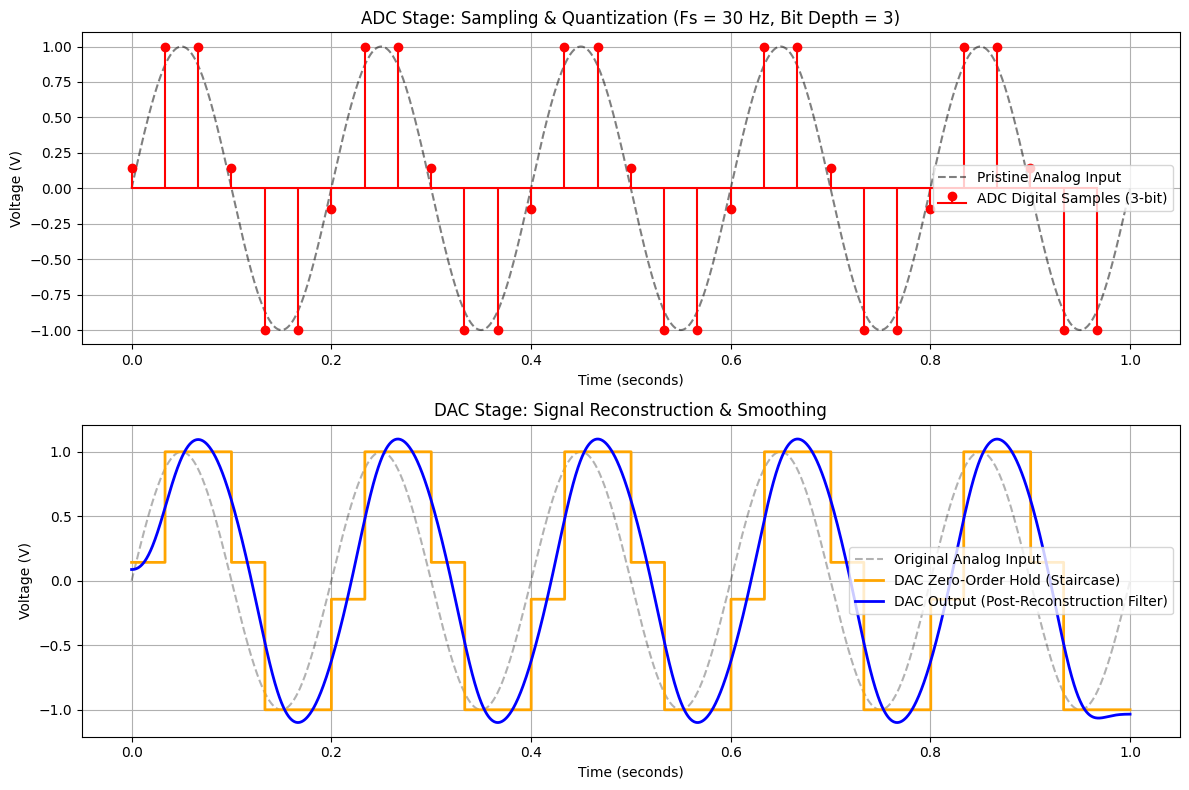

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

def run_adc_dac_simulation(analog_freq=5, sampling_rate=25, bit_depth=3):
    """
    Simulates the entire pipeline of an Analog-to-Digital Converter (ADC)
    and a Digital-to-Analog Converter (DAC) with adjustable artifacts.
    """
    # 1. Setup Environment
    t_analog = np.linspace(0, 1, 2000) # Simulates a continuous analog timeline
    v_max, v_min = 1.0, -1.0           # Dynamic Range of the ADC/DAC hardware

    # Generate the pristine analog input signal
    signal_analog = np.sin(2 * np.pi * analog_freq * t_analog)

    # 2. THE ADC LAYER
    # Step A: Sampling (Time Discretization)
    t_sampled = np.arange(0, 1, 1.0 / sampling_rate)
    signal_sampled = np.sin(2 * np.pi * analog_freq * t_sampled)

    # Step B: Quantization (Amplitude Discretization)
    levels = 2 ** bit_depth
    # Scale signal to [0, levels - 1] space, round to integers, and scale back
    signal_scaled = (signal_sampled - v_min) / (v_max - v_min) * (levels - 1)
    signal_quantized_int = np.clip(np.round(signal_scaled), 0, levels - 1)
    signal_adc_output = (signal_quantized_int / (levels - 1)) * (v_max - v_min) + v_min

    # 3. THE DAC LAYER
    # Step A: Zero-Order Hold (Staircase reconstruction)
    # We step through time, holding the last digital value received
    signal_dac_staircase = np.zeros_like(t_analog)
    for i, t in enumerate(t_sampled):
        idx = t_analog >= t
        signal_dac_staircase[idx] = signal_adc_output[i]

    # Step B: Reconstruction Filtering (Smoothing)
    # An ideal DAC cuts off frequencies above the Nyquist limit (sampling_rate / 2)
    nyquist_limit = sampling_rate / 2.0
    # Create an analog lowpass butterworth filter
    b, a = signal.butter(N=4, Wn=nyquist_limit, fs=2000, btype='low')
    signal_dac_smoothed = signal.filtfilt(b, a, signal_dac_staircase)

    # 4. PLOTTING THE DISTORTION
    plt.figure(figsize=(12, 8))

    # Subplot 1: The ADC Domain
    plt.subplot(2, 1, 1)
    plt.plot(t_analog, signal_analog, label="Pristine Analog Input", color='black', alpha=0.5, linestyle='--')
    plt.stem(t_sampled, signal_adc_output, linefmt='r-', markerfmt='ro', basefmt='r-', label=f"ADC Digital Samples ({bit_depth}-bit)")
    plt.title(f"ADC Stage: Sampling & Quantization (Fs = {sampling_rate} Hz, Bit Depth = {bit_depth})")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (V)")
    plt.grid(True)
    plt.legend()

    # Subplot 2: The DAC Domain
    plt.subplot(2, 1, 2)
    plt.plot(t_analog, signal_analog, label="Original Analog Input", color='black', alpha=0.3, linestyle='--')
    plt.plot(t_analog, signal_dac_staircase, label="DAC Zero-Order Hold (Staircase)", color='orange', drawstyle='steps-post', linewidth=2)
    plt.plot(t_analog, signal_dac_smoothed, label="DAC Output (Post-Reconstruction Filter)", color='blue', linewidth=2)
    plt.title("DAC Stage: Signal Reconstruction & Smoothing")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (V)")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Run the simulation with low specs to deliberately view artifacts
run_adc_dac_simulation(analog_freq=5, sampling_rate=30, bit_depth=3)

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

def interactive_adc_dac(analog_freq=5.0, sampling_rate=40, bit_depth=3):
    """
    Renders the ADC/DAC simulation plots dynamically based on slider values.
    """
    # 1. Continuous timeline vs discrete timeline
    t_analog = np.linspace(0, 1, 2000)
    v_max, v_min = 1.0, -1.0
    signal_analog = np.sin(2 * np.pi * analog_freq * t_analog)

    # 2. ADC Stage
    t_sampled = np.arange(0, 1, 1.0 / sampling_rate)
    signal_sampled = np.sin(2 * np.pi * analog_freq * t_sampled)

    # Quantization calculations
    levels = 2 ** bit_depth
    signal_scaled = (signal_sampled - v_min) / (v_max - v_min) * (levels - 1)
    signal_quantized_int = np.clip(np.round(signal_scaled), 0, levels - 1)
    signal_adc_output = (signal_quantized_int / (levels - 1)) * (v_max - v_min) + v_min

    # 3. DAC Stage
    signal_dac_staircase = np.zeros_like(t_analog)
    for i, t in enumerate(t_sampled):
        idx = t_analog >= t
        signal_dac_staircase[idx] = signal_adc_output[i]

    # Reconstruction Filtering (Nyquist tracking)
    nyquist_limit = sampling_rate / 2.0

    # Guardrail: Filter cutoff must be strictly less than half the simulation scale (1000 Hz)
    if nyquist_limit >= 999:
        nyquist_limit = 999

    b, a = signal.butter(N=4, Wn=nyquist_limit, fs=2000, btype='low')
    signal_dac_smoothed = signal.filtfilt(b, a, signal_dac_staircase)

    # 4. Rendering Graphical Output
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))

    # Top Plot: Digital Domain
    ax1.plot(t_analog, signal_analog, color='black', alpha=0.3, linestyle='--', label="Input")
    ax1.stem(t_sampled, signal_adc_output, linefmt='r-', markerfmt='ro', basefmt='r-', label="Digital Samples")
    ax1.set_title(f"ADC Sampling Space (Bit Depth Resolution Levels: {levels})")
    ax1.set_ylabel("Voltage (V)")
    ax1.grid(True)
    ax1.legend(loc="upper right")

    # Bottom Plot: Analog Reconstruction Domain
    ax2.plot(t_analog, signal_analog, color='black', alpha=0.2, linestyle='--', label="Original Input")
    ax2.plot(t_analog, signal_dac_staircase, color='orange', drawstyle='steps-post', alpha=0.6, label="ZOH Staircase")
    ax2.plot(t_analog, signal_dac_smoothed, color='blue', linewidth=2, label="Filtered Output")

    # Check for Aliasing Warning
    if sampling_rate <= (2 * analog_freq):
        ax2.text(0.35, 0.85, "⚠️ ALIASING CRITICAL ERROR", color='red', weight='bold',
                   fontsize=12, transform=ax2.transAxes, bbox=dict(facecolor='white', alpha=0.8))

    ax2.set_title("DAC Physical Output Reconstruction")
    ax2.set_xlabel("Time (seconds)")
    ax2.set_ylabel("Voltage (V)")
    ax2.grid(True)
    ax2.legend(loc="upper right")

    plt.tight_layout()
    plt.show()

# Create the interactive control cockpit dashboard
interact(
    interactive_adc_dac,
    analog_freq = FloatSlider(min=1.0, max=15.0, step=0.5, value=5.0, description='Signal Freq (Hz)'),
    sampling_rate = IntSlider(min=6, max=150, step=2, value=40, description='Sample Rate (Hz)'),
    bit_depth = IntSlider(min=1, max=8, step=1, value=3, description='Bit Depth (Bits)')
);

interactive(children=(FloatSlider(value=5.0, description='Signal Freq (Hz)', max=15.0, min=1.0, step=0.5), Int…